## Project Objective

**Author:** Aman Sharma  
**Date:** April 2026

A single piece of text may contain multiple discourse types, each serving a different rhetorical function. The aim of this project is to train a model capable of classifying text segments into distinct discourse categories.

The available dataset contains thousands of texts, each fully annotated — or "disintegrated" — into discourse-level labels. The model will learn to assign one of the following seven classes to each relevant segment:

---

### Discourse Classes

| Class | Description |
|-------|-------------|
| **Lead** | Introductory or opening statement |
| **B-Position** | Beginning position or stance |
| **Claim** | Main assertion or thesis |
| **Counterclaim** | Opposing argument |
| **Rebuttal** | Response to counterclaim |
| **Evidence** | Supporting data or examples |
| **Concluding Statement** | Final or concluding remarks |

---

## Task Formulation

This is a token-level classification task (similar to Named Entity Recognition), where each token or sentence segment is assigned a discourse label. The model must learn to identify rhetorical boundaries and classify text spans accordingly.

---

## Dataset Description

- **Source:** Thousands of annotated texts
- **Annotation Style:** Full text disintegrated into discourse units
- **Label Set:** 7 discourse classes (as listed above)
- **Task:** Predict discourse label for each text segment


In [1]:
import os
import gc
import ast
import time
#import wandb
from tqdm import tqdm
from collections import defaultdict

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

import torch
from torch.utils.data import Dataset, DataLoader


from transformers import AutoConfig, AutoTokenizer, AutoModelForTokenClassification

#from train import *
#from utils import *
#from const import *
#from validation import *

dftrainorg = pd.read_csv(r"C:\Users\lenovo\Downloads\pytorch\roberta\data\train.csv")
print(dftrainorg.shape)
display(dftrainorg.head())

(144293, 8)


,id,discourse_id,discourse_start,discourse_end,discourse_text,discourse_type,discourse_type_num,predictionstring
0,423A1CA112E2,1.622628e+12,8.0,229.0,Modern humans today are always on their phone....,Lead,Lead 1,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...
1,423A1CA112E2,1.622628e+12,230.0,312.0,They are some really bad consequences when stu...,Position,Position 1,45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
2,423A1CA112E2,1.622628e+12,313.0,401.0,Some certain areas in the United States ban ph...,Evidence,Evidence 1,60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75
3,423A1CA112E2,1.622628e+12,402.0,758.0,"When people have phones, they know about certa...",Evidence,Evidence 2,76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 9...
4,423A1CA112E2,1.622628e+12,759.0,886.0,Driving is one of the way how to get around. P...,Claim,Claim 1,139 140 141 142 143 144 145 146 147 148 149 15...


In [2]:
dftrainorgcopy = dftrainorg.copy()
dftrainorgcopy.head()

,id,discourse_id,discourse_start,discourse_end,discourse_text,discourse_type,discourse_type_num,predictionstring
0,423A1CA112E2,1.622628e+12,8.0,229.0,Modern humans today are always on their phone....,Lead,Lead 1,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...
1,423A1CA112E2,1.622628e+12,230.0,312.0,They are some really bad consequences when stu...,Position,Position 1,45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
2,423A1CA112E2,1.622628e+12,313.0,401.0,Some certain areas in the United States ban ph...,Evidence,Evidence 1,60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75
3,423A1CA112E2,1.622628e+12,402.0,758.0,"When people have phones, they know about certa...",Evidence,Evidence 2,76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 9...
4,423A1CA112E2,1.622628e+12,759.0,886.0,Driving is one of the way how to get around. P...,Claim,Claim 1,139 140 141 142 143 144 145 146 147 148 149 15...


In [3]:
dftrainorgcopy["discourselen"] = dftrainorgcopy["discourse_text"].apply(lambda x : len(x.split()))
dftrainorgcopy["predlen"]      = dftrainorgcopy["predictionstring"].apply(lambda x : len(x.split()))

colstodisplay=["discourse_id", "discourse_text" , "discourse_type" , "predictionstring" , "discourselen" , "predlen"]

dftrainorgcopy[colstodisplay].head()

,discourse_id,discourse_text,discourse_type,predictionstring,discourselen,predlen
0,1.622628e+12,Modern humans today are always on their phone....,Lead,1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 1...,44,44
1,1.622628e+12,They are some really bad consequences when stu...,Position,45 46 47 48 49 50 51 52 53 54 55 56 57 58 59,15,15
2,1.622628e+12,Some certain areas in the United States ban ph...,Evidence,60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75,16,16
3,1.622628e+12,"When people have phones, they know about certa...",Evidence,76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 9...,63,63
4,1.622628e+12,Driving is one of the way how to get around. P...,Claim,139 140 141 142 143 144 145 146 147 148 149 15...,24,24


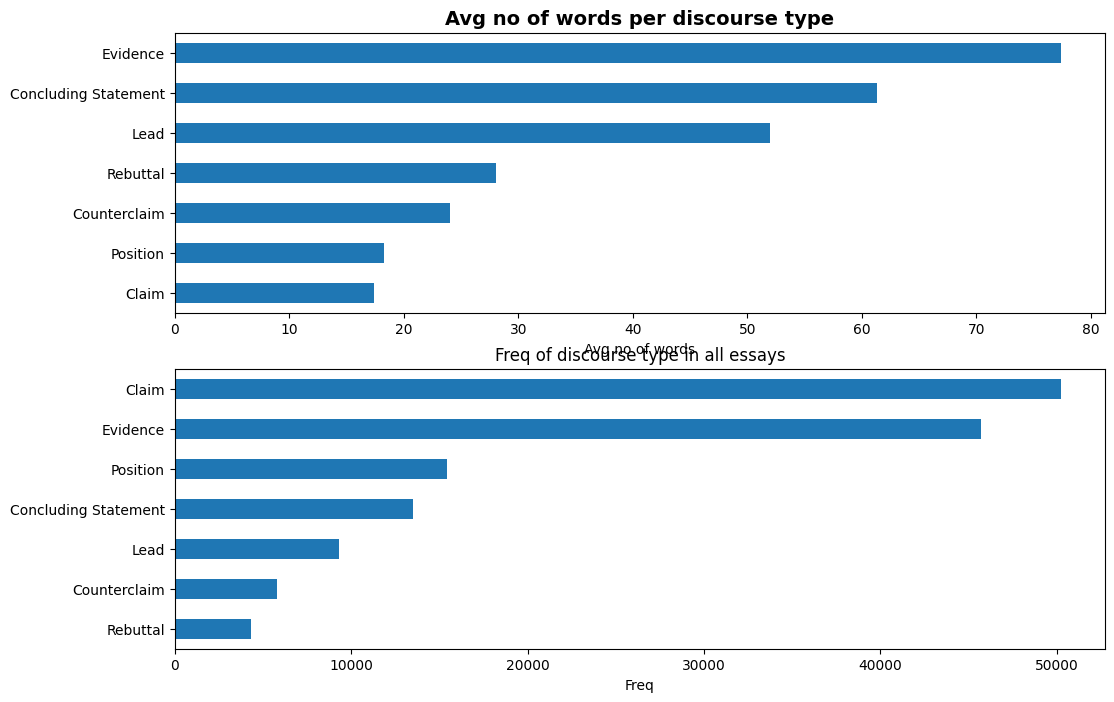

In [4]:

import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter

fig = plt.figure(figsize=(12,8))

ax1 = fig.add_subplot(211)

ax1 = dftrainorgcopy.groupby("discourse_type")["discourselen"].mean().sort_values().plot(kind="barh")

ax1.set_title("Avg no of words per discourse type" , fontsize =14 , fontweight = "bold")

ax1.set_xlabel("Avg no of words", fontsize= 10)

ax1.set_ylabel("")

ax2 = fig.add_subplot(212)

ax2 = dftrainorgcopy.groupby("discourse_type")["discourse_type"].count().sort_values().plot(kind="barh")

ax2.set_title("Freq of discourse type in all essays")
ax2.set_xlabel("Freq")
ax2.set_ylabel("")
plt.show()

Data Preparation

In [5]:
def attachnertotext(inputdir:str, outputfile:str, dftrainorg: pd.DataFrame) -> pd.DataFrame:
    trainnames,traintexts = [],[]
    for f in tqdm(list(os.listdir(inputdir))):
        trainnames.append(f.replace(".txt", ""))
        traintexts.append(open(inputdir + f , "r").read())

    dfnertexts = pd.DataFrame({"id": trainnames , "text": traintexts})
    dfnertexts["text_split"] = dfnertexts.text.str.split()
    allents = []
    for _,row in tqdm(dfnertexts.iterrows() , total =len(dfnertexts)):
        total = len(row["text_split"])
        entities = ["O"]*total
        for _,row2 in dftrainorg[dftrainorg["id"] == row["id"]].iterrows():
            discourse = row2["discourse_type"] 
            listix = [int(x) for x in row2["predictionstring"].split(" ")]

            validinds = [idx for idx in listix if idx < total]

            entities[validinds[0]] = f"B-{discourse}"
            for k in validinds[1:]:
                entities[k] = f"I-{discourse}"
        allents.append(entities)

    dfnertexts["entities"] = allents
    dfnertexts.to_csv(outputfile,index = False)
    return(dfnertexts) 


In [6]:

inputdir = r"C:/Users/lenovo/Downloads/pytorch/roberta/data/train/"
outputfile = "trainner.csv"

dfnertexts = attachnertotext(inputdir,outputfile, dftrainorg)

100%|████████████████████████████████████████████████████████████████████████████| 15594/15594 [02:48<00:00, 92.59it/s]


In [7]:
idsallunique =  dftrainorg.id.unique()
len(idsallunique)

15594

Train test Split

In [8]:
import numpy as np
np.random.seed(42)

trainidx = np.random.choice(np.arange(len(idsallunique)) , int(0.9*len(idsallunique)) , replace = False)

valididx = np.setdiff1d(np.arange(len(trainidx)), trainidx)

np.random.seed(None)

dftrain = dfnertexts.loc[dfnertexts["id"].isin(idsallunique[trainidx])].reset_index(drop=True)
dfval   = dfnertexts.loc[dfnertexts["id"].isin(idsallunique[valididx])].reset_index(drop=True)





In [9]:

maxlen = 512
docstride = 128

modelname = "roberta-large"
modelpath = "model"

config = {"trainbatchsize":  1,
          "validbatchsize": 1,
          "epochs": 5,
          "lrnrt": [2.5e-5 , 2.5e-5 , 2.5e-6, 2.5e-6, 2.5e-7],
          "maxgradnorm": 10,
          "maxlen": maxlen,
          "docstride": docstride,
          "device": "cpu"}

outputlabels = ["O", "B-Lead", "I-Lead" , "B-Position", "I-Position" ,
                 "B-Claim", "I-Claim" , "B-Counterclaim", "I-Counterclaim" , "B-Rebuttal", "I-Rebuttal" ,
                 "B-Evidence", "I-Evidence" , "B-Concluding Statement", "I-Concluding Statement"]


labelstoids = {v:k for k,v in enumerate(outputlabels)}
idtolabels = {k:v for k,v in enumerate(outputlabels)}



def downloadhfmodel(modelpath,modelname):
    if not os.path.exists(modelpath):
        os.makedirs(modelpath)
    tokenizer = AutoTokenizer.from_pretrained(modelname , add_prefix_space = True)
    tokenizer.save_pretrained(modelpath)
    configmodel = AutoConfig.from_pretrained(modelname)
    configmodel.num_labels=15
    configmodel.save_pretrained(modelpath)

    backbone = AutoModelForTokenClassification.from_pretrained(modelname,config=configmodel)
    backbone.save_pretrained(modelpath)

In [10]:
downloadhfmodel(modelpath,modelname)

Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenize

In [11]:
import torch

def getlabelsforwords(wordids,wordlabels,labelstoids):
    labelids = []
    for wordidx in wordids:
        if wordidx is None:
            labelids.append(-100)
        else:
            labelids.append(labelstoids[wordlabels[wordidx]])

    return(labelids)


def tokenize(df, tokenizer, docstride,maxlen, labelstoids, totensor= True, getlabels= True):
    encoded = tokenizer(df["text_split"].tolist(),
                        is_split_into_words=True,
                        return_overflowing_tokens = True,
                        stride = docstride,
                        max_length = maxlen,
                        padding = "max_length",
                        truncation = True)
    if getlabels:
        encoded["labels"] = []
    encoded["wids"] = []
    n = len(encoded["overflow_to_sample_mapping"])
    for i in range(n):
        textidx = encoded["overflow_to_sample_mapping"][i]
        wordids = encoded.word_ids(i)
        if getlabels:
            wordlabels = df["entities"].iloc[textidx]
            labelids = getlabelsforwords(wordids,wordlabels,labelstoids)
            encoded["labels"].append(labelids)
        encoded["wids"].append([w if w is not None else -1 for w in wordids])

    if totensor:
        encoded = {key: torch.as_tensor(val) for key,val in encoded.items()}

    return(encoded)




tokenizer = AutoTokenizer.from_pretrained(modelpath)

tokenizedtrain= tokenize(dftrain, tokenizer, docstride, maxlen , labelstoids)
tokenizedval = tokenize(dfval, tokenizer, docstride, maxlen , labelstoids)

In [12]:
class dataloaderclass(Dataset):
    def __init__(self,tokenizedds):
        self.data = tokenizedds

    def __getitem__(self,index):
        item = {k: self.data[k][index] for k in self.data.keys()}

        return(item)
    
    def __len__(self):
        return(len(self.data["input_ids"]))
    

dstrain = dataloaderclass(tokenizedtrain)
dsval = dataloaderclass(tokenizedval)


dataloadertrain = DataLoader(dstrain , batch_size = config["trainbatchsize"],
                            shuffle = True, num_workers = 0 , pin_memory = False)
dataloaderval  = DataLoader(dsval , batch_size = config["validbatchsize"],
                            shuffle = False, num_workers = 0 , pin_memory = False)





In [13]:
configmodel = AutoConfig.from_pretrained(modelpath)
model = AutoModelForTokenClassification.from_pretrained(modelpath,config = configmodel)
model.to(config["device"])

RobertaForTokenClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)


In [14]:
uniquevalidids = idsallunique[valididx]

#dfvalid = dftrainorg.loc[dftrainorg["id"].isin(uniquevalidids)]

Train and validate

In [15]:
def train(model, optimizer, dataloadertrain, epoch):
    timestart = time.time()

    for g in optimizer.param_groups:
        g["lr"] = config["lrnrt"][epoch]

    lr =optimizer.param_groups[0]["lr"]
    epochprefix = f"[Epoch{epoch+1:2d} / {config['epochs']:2d}]"
    print(f"{epochprefix} Starting epoch {epoch+1:2d} with LR = {lr}")

    model.train()

    trloss, traccuracy = 0,0

    numtrainexamples, numtrainbatches= 0,0

    for idx,batch in enumerate(dataloadertrain):
        ids = batch["input_ids"].to(config["device"] , dtype = torch.long)
        mask = batch["attention_mask"].to(config["device"] , dtype = torch.long)
        labels = batch["labels"].to(config["device"] , dtype = torch.long)
        loss, rawlogits = model(input_ids=ids, attention_mask = mask , labels = labels,
                                return_dict = False)
        trloss += loss.item()
        numtrainbatches += 1
        numtrainexamples += labels.size(0)
        lossstep = trloss/ numtrainbatches
        if idx % 10 == 0 :
            print(f"{epochprefix}    Steps:{idx:4d} -->  Loss :{lossstep:.4f}")
        
        flattenedlabels = labels.view(-1)
        activelogits = rawlogits.view(-1, model.num_labels)
        flattdpredicts = torch.argmax(activelogits , axis = 1)

        activeacc = labels.view(-1) != -100
        labels = torch.masked_select(flattenedlabels,activeacc)
        predictions = torch.masked_select(flattdpredicts,activeacc)

        tmptraccuracy = accuracy_score(labels.cpu().numpy(), predictions.cpu().numpy())

        traccuracy += tmptraccuracy

        torch.nn.utils.clip_grad_norm_(
            parameters = model.parameters(), max_norm = config["maxgradnorm"]
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    epochloss = trloss / numtrainbatches
    traccuracy = traccuracy / numtrainbatches

    torch.save(model.state_dict(), modelpath)
    torch.cuda.empty_cache()
    gc.collect()
    elapsed = time.time() - timestart

   
    print(f"{epochprefix} Training loss     : {epochloss: .4f}")
    print(f"{epochprefix} Training accuracy : {traccuracy: .4f}")
    print(f"Time elapsed: {elapsed/60:.2f} mins")  




Validation

In [16]:
def inference(dl,model):
    predictions = defaultdict(list) 
    seenwordsidx = defaultdict(list)

    for batch in dl:
        ids = batch["input_ids"].to(config["device"])
        mask = batch["attention_mask"].to(config["device"])
        outputs = model(ids , attention_mask=mask, return_dict = False )
        del ids, mask

        batchpreds = torch.argmax(outputs[0], axis = -1).cpu().numpy()

        for k, (chunkpreds,textid) in enumerate(zip(batchpreds , batch["overflow_to_sample_mapping"].tolist())):
            wordids = batch["wids"][k].numpy()
            chunkpreds = [idstolabels[i] for i in chunkpreds]
            for idx, wordidx in enumerate(wordids):
                if wordidx == -1 :
                    pass
                elif wordidx not in seenwordsidx[textid]:
                    predictions[textid].append(chunkpreds[idx])
                    seenwordsidx[textid].append(wordidx)

    finalpreds = [predictions[k] for k in sorted(predictions.keys())]
    return(finalpreds)


def getpreds(df,dl,model):
    predlabels = inference(dl,model)
    finalpreds=[]
    for i in range(len(df)):
        idx = df.id.values[i]
        pred = predlabels[i]
        j=0
        while j<len(pred):
            cls = pred[j]
            if cls == "O": 
                pass
            else: 
                cls = cls.replace("B","I")
            end = j+1

            while end< len(pred) and pred[end] == cls:
                end += 1
            if cls != "O" and cls != "" and end-j>7:
                finalpreds.append((idx, cls.replace("I-",""), 
                                   " ".join(map(str,list(range(j,end))))))
                
            j = end

    dfpred = pd.DataFrame(finalpreds)

    dfpred.columns = ["id" , "class" , "predictionstring"]

    dfpred.head(2)

    return(dfpred)

        

def validate(model,dftrainorg,dfval, dataloaderval, epoch, uniquevalidlist):
    timestart = time.time()
    model.eval()

    dfvalid = dftrainorg.loc[dftrainorg["id"].isin(uniquevalididlist)]
    outoffold = getpreds(dfval ,dataloaderval, model)

    f1s = []

    classes = outoffold["class"].unique()

    epochprefix = f"[Epoch{epoch+1:2d} / {config['epochs'] :2d}]"

    print(f"{epochprefix} Validation F1 scores")

    f1s_log = {}

    for c in classes:
        preddf = outoffold.loc[outoffold["class"] == c].copy()
        getdf = dfval.loc[dfval["class"] == c].copy()

        f1 = computemacrof1score(preddf, getdf)

        print(f"{epochprefix} * {c:<10} : {f1 : 4f}")

        f1s.append(f1)
        f1s_log[f'F1{c}'] = f1
    
    elapsed = time.time() - timestart

    print(epochprefix)
    print(f'{epochprefix} Overall validtion f1 : {np.mean(f1s): .4f} [{elapsed: .4f} secs]')
    print(epochprefix)
    f1s_log["Overall F1"] = np.mean(f1s)    

In [16]:
optimizer = torch.optim.Adam(params = model.parameters(), lr = config['lrnrt'][0])

for epoch in range(config['epochs']):
    print()
    train(model,optimizer,dataloadertrain,epoch)
    validate(model,dftrainorg,dfval, dataloaderval,epoch, idsallunique) 

torch.save(model.state_dict(),modelpath) 


[Epoch 1 /  5] Starting epoch  1 with LR = 2.5e-05
[Epoch 1 /  5]    Steps:   0 -->  Loss :2.9176
[Epoch 1 /  5]    Steps:  10 -->  Loss :2.1436
[Epoch 1 /  5]    Steps:  20 -->  Loss :1.9628
[Epoch 1 /  5]    Steps:  30 -->  Loss :1.9095
[Epoch 1 /  5]    Steps:  40 -->  Loss :1.8193
[Epoch 1 /  5]    Steps:  50 -->  Loss :1.7719
[Epoch 1 /  5]    Steps:  60 -->  Loss :1.7280
[Epoch 1 /  5]    Steps:  70 -->  Loss :1.7048
[Epoch 1 /  5]    Steps:  80 -->  Loss :1.6693
[Epoch 1 /  5]    Steps:  90 -->  Loss :1.6591
[Epoch 1 /  5]    Steps: 100 -->  Loss :1.6077
[Epoch 1 /  5]    Steps: 110 -->  Loss :1.5929
[Epoch 1 /  5]    Steps: 120 -->  Loss :1.5597
[Epoch 1 /  5]    Steps: 130 -->  Loss :1.5417
[Epoch 1 /  5]    Steps: 140 -->  Loss :1.5122
[Epoch 1 /  5]    Steps: 150 -->  Loss :1.5016
[Epoch 1 /  5]    Steps: 160 -->  Loss :1.4927
[Epoch 1 /  5]    Steps: 170 -->  Loss :1.4915
[Epoch 1 /  5]    Steps: 180 -->  Loss :1.4772
[Epoch 1 /  5]    Steps: 190 -->  Loss :1.4684
[Epoch 1


KeyboardInterrupt



KeyboardInterrupt: 

In [ ]:
outoffold = getpreds(dfval, dataloaderval,model)